# Hotel Dataset

# Library Package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kstest
import math
from sklearn.preprocessing import MinMaxScaler

# Load Dataset

In [3]:
# Load csv dataset
df = pd.read_csv('train-3.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83288,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,9.0,NaN,0,Transient,169.00,1,1,Check-Out,2018-10-27,83289
83289,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,9.0,NaN,0,Transient,94.50,0,2,Check-Out,2017-09-18,83290
83290,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,NaN,NaN,0,Transient,123.50,0,1,Check-Out,2019-07-05,83291
83291,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,9.0,NaN,0,Transient,122.25,0,1,Check-Out,2018-08-06,83292


In [726]:
# Display all columns in the DataFrame
pd.set_option('display.max_columns', None)

| Column Name | Category | Description |
|------------|----------|------------|
| bookingID | Identifier | Unique identifier for each booking record |
| is_canceled | Outcome | Indicates whether the booking was canceled (1 = Yes, 0 = No) |
| lead_time | Booking Info | Number of days between booking date and arrival date |
| arrival_date_year | Booking Info | Year of arrival |
| arrival_date_week_number | Booking Info | Week number of arrival within the year |
| arrival_date_day_of_month | Booking Info | Day of the month of arrival |
| stays_in_weekend_nights | Stay Info | Number of weekend nights (Saturday/Sunday) stayed |
| stays_in_week_nights | Stay Info | Number of weekday nights (Monday–Friday) stayed |
| adults | Customer Info | Number of adults in the booking |
| children | Customer Info | Number of children in the booking |
| babies | Customer Info | Number of babies in the booking |
| customer_type | Customer Info | Group – when the booking is associated to a group; Transient – when the booking is not part of a group or contract, and is not associated to other transient booking; Transient-party – when the booking is transient, but is associated to at least other transient booking |
| adr | Pricing | Average Daily Rate (average price per night) |
| market_segment | Channel |Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators” |
| distribution_channel | Channel | Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators” |
| agent | Channel | ID of the travel agent handling the booking |
| company | Channel | ID of the company for corporate bookings |
| booking_changes | Booking Info | Number of changes made to the booking |
| is_repeated_guest | Customer Behavior | Indicates if the guest is a returning customer (1 = Yes, 0 = No) |
| deposit_type | Booking Info | Type of deposit made (No Deposit, Refundable, Non Refund) |
| days_in_waiting_list | Booking Info | Number of days the booking was on the waiting list |
| reserved_room_type | Room Info | Type of room originally reserved |
| assigned_room_type | Room Info | Type of room actually assigned to the guest |
| required_car_parking_spaces | Service | Number of parking spaces required |
| total_of_special_requests | Service | Number of special requests made by the customer |
| meal | Service | Type of meal plan booked (BB, HB, FB, SC) |
| reservation_status | Outcome | Final reservation status (Check-Out, Canceled, No-Show) |
| previous_cancellations | Customer Behavior | Number of previous bookings that were canceled by the customer |
| previous_bookings_not_canceled | Customer Behavior | Number of previous bookings that were not canceled |

# Data Exploration

In [727]:
# Cek ukuran data
print("Shape:", df.shape)

Shape: (83293, 33)


In [728]:
# cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

In [729]:
# cek statistik data
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83290.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,71889.000000,4734.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,2018.156808,27.164023,15.786116,0.930390,2.503812,1.854466,0.103614,0.008032,0.030243,0.086994,0.141765,0.223068,86.867282,190.003802,2.352238,101.724373,0.061818,0.571945,41647.000000
std,0.482673,106.874124,0.706656,13.623752,8.775931,1.004196,1.924511,0.606139,0.398821,0.100641,0.171255,0.862988,1.554390,0.656237,110.875605,131.969152,17.820652,48.082552,0.245027,0.793742,24044.762323
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,183.000000,0.000000,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,70.000000,21.000000,535.000000,543.000000,391.000000,508.000000,8.000000,5.000000,83293.000000


In [730]:
# Check the number and percentage of missing values
missing_data = df.isna().sum()
missing_percentage = round((missing_data / len(df) * 100), 2)

# Convert missing values into a DataFrame
missing_df = pd.DataFrame(
    {'missing_number': missing_data,
     'missing_percentage': missing_percentage}
)

# Filter out columns with no missing values
missing_df = missing_df[missing_df['missing_number'] > 0]

# Sort by highest percentage and number of missing values
missing_df.sort_values(by=['missing_percentage', 'missing_number'], ascending=False)

,missing_number,missing_percentage
company,78559,94.32
agent,11404,13.69
country,346,0.42
children,3,0.00


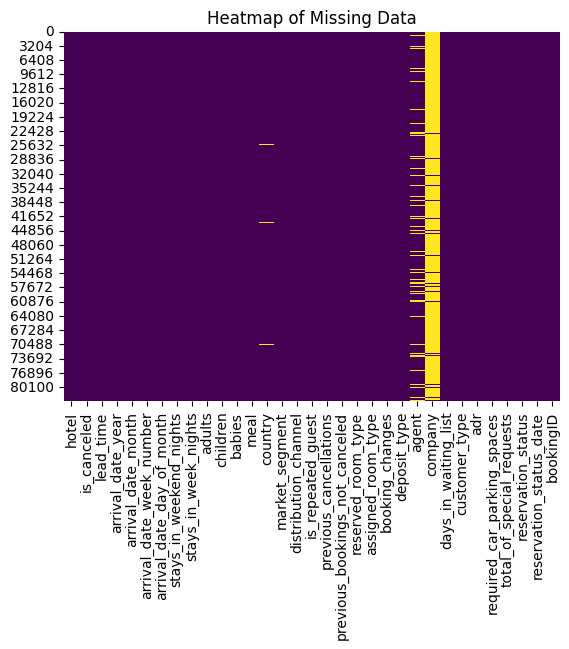

In [731]:
# Visualize missing data using a heatmap
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data')
plt.show()

Although the PMS database shows no missing values, the "NULL" label appears in categories like "Agent" or "Company." This should be interpreted as "not applicable" rather than a missing entry; a "NULL" agent simply means the guest booked directly.

In [732]:
print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())


=== DUPLICATES ===
Duplicate rows: 0


In [733]:
# cek data unik
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)


hotel
['Crystal Cove, Barbados Barbados' 'Greensboro Courtyard Greensboro, NC'
 'The Westin Peachtree Plaza, Atlanta Atlanta, GA '
 'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom'
 'W New York – Union Square New York, NY'
 'Hotel Maria Cristina, San Sebastian San Sebastian, Spain'
 'W New York – Times Square New York, NY'
 'The Ritz-Carlton, Tokyo Tokyo, Japan'
 'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico'
 'Las Vegas Marriott Las Vegas, NV '
 'Heidelberg Marriott Hotel Heidelberg, Germany'
 'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil'
 'Renaissance Hamburg Hotel Hamburg, Germany'
 'The Ritz-Carlton, Berlin Berlin, Germany'
 'Sheraton Lima Hotel & Convention Center Lima, Peru'
 'Courtyard Las Vegas Convention Center Las Vegas, NV '
 'Newark Liberty International Airport Courtyard Newark, NJ'
 'Indianapolis Airport Courtyard Indianapolis, IN'
 'Treasure Beach, Barbados Barbados'
 'Cape Town Marriott Hotel Crystal Towers Cape Town, South

In [734]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    # Standarisasi (Z-score)
    data_z = (df[col] - df[col].mean()) / df[col].std()

    # Drop NA jika ada
    data_z = data_z.dropna()

    # Uji KS
    stat, p = kstest(data_z, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("  ➜ Data berdistribusi normal\n")
    else:
        print("  ➜ Data tidak berdistribusi normal\n")

Kolom: is_canceled
  Statistik uji : 0.4085
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: lead_time
  Statistik uji : 0.1654
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: arrival_date_year
  Statistik uji : 0.2474
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: arrival_date_week_number
  Statistik uji : 0.0530
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: arrival_date_day_of_month
  Statistik uji : 0.0746
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: stays_in_weekend_nights
  Statistik uji : 0.2582
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: stays_in_week_nights
  Statistik uji : 0.2026
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: adults
  Statistik uji : 0.3962
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: children
  Statistik uji : 0.5309
  p-value       : 0.000000
  ➜ Data tidak berdis

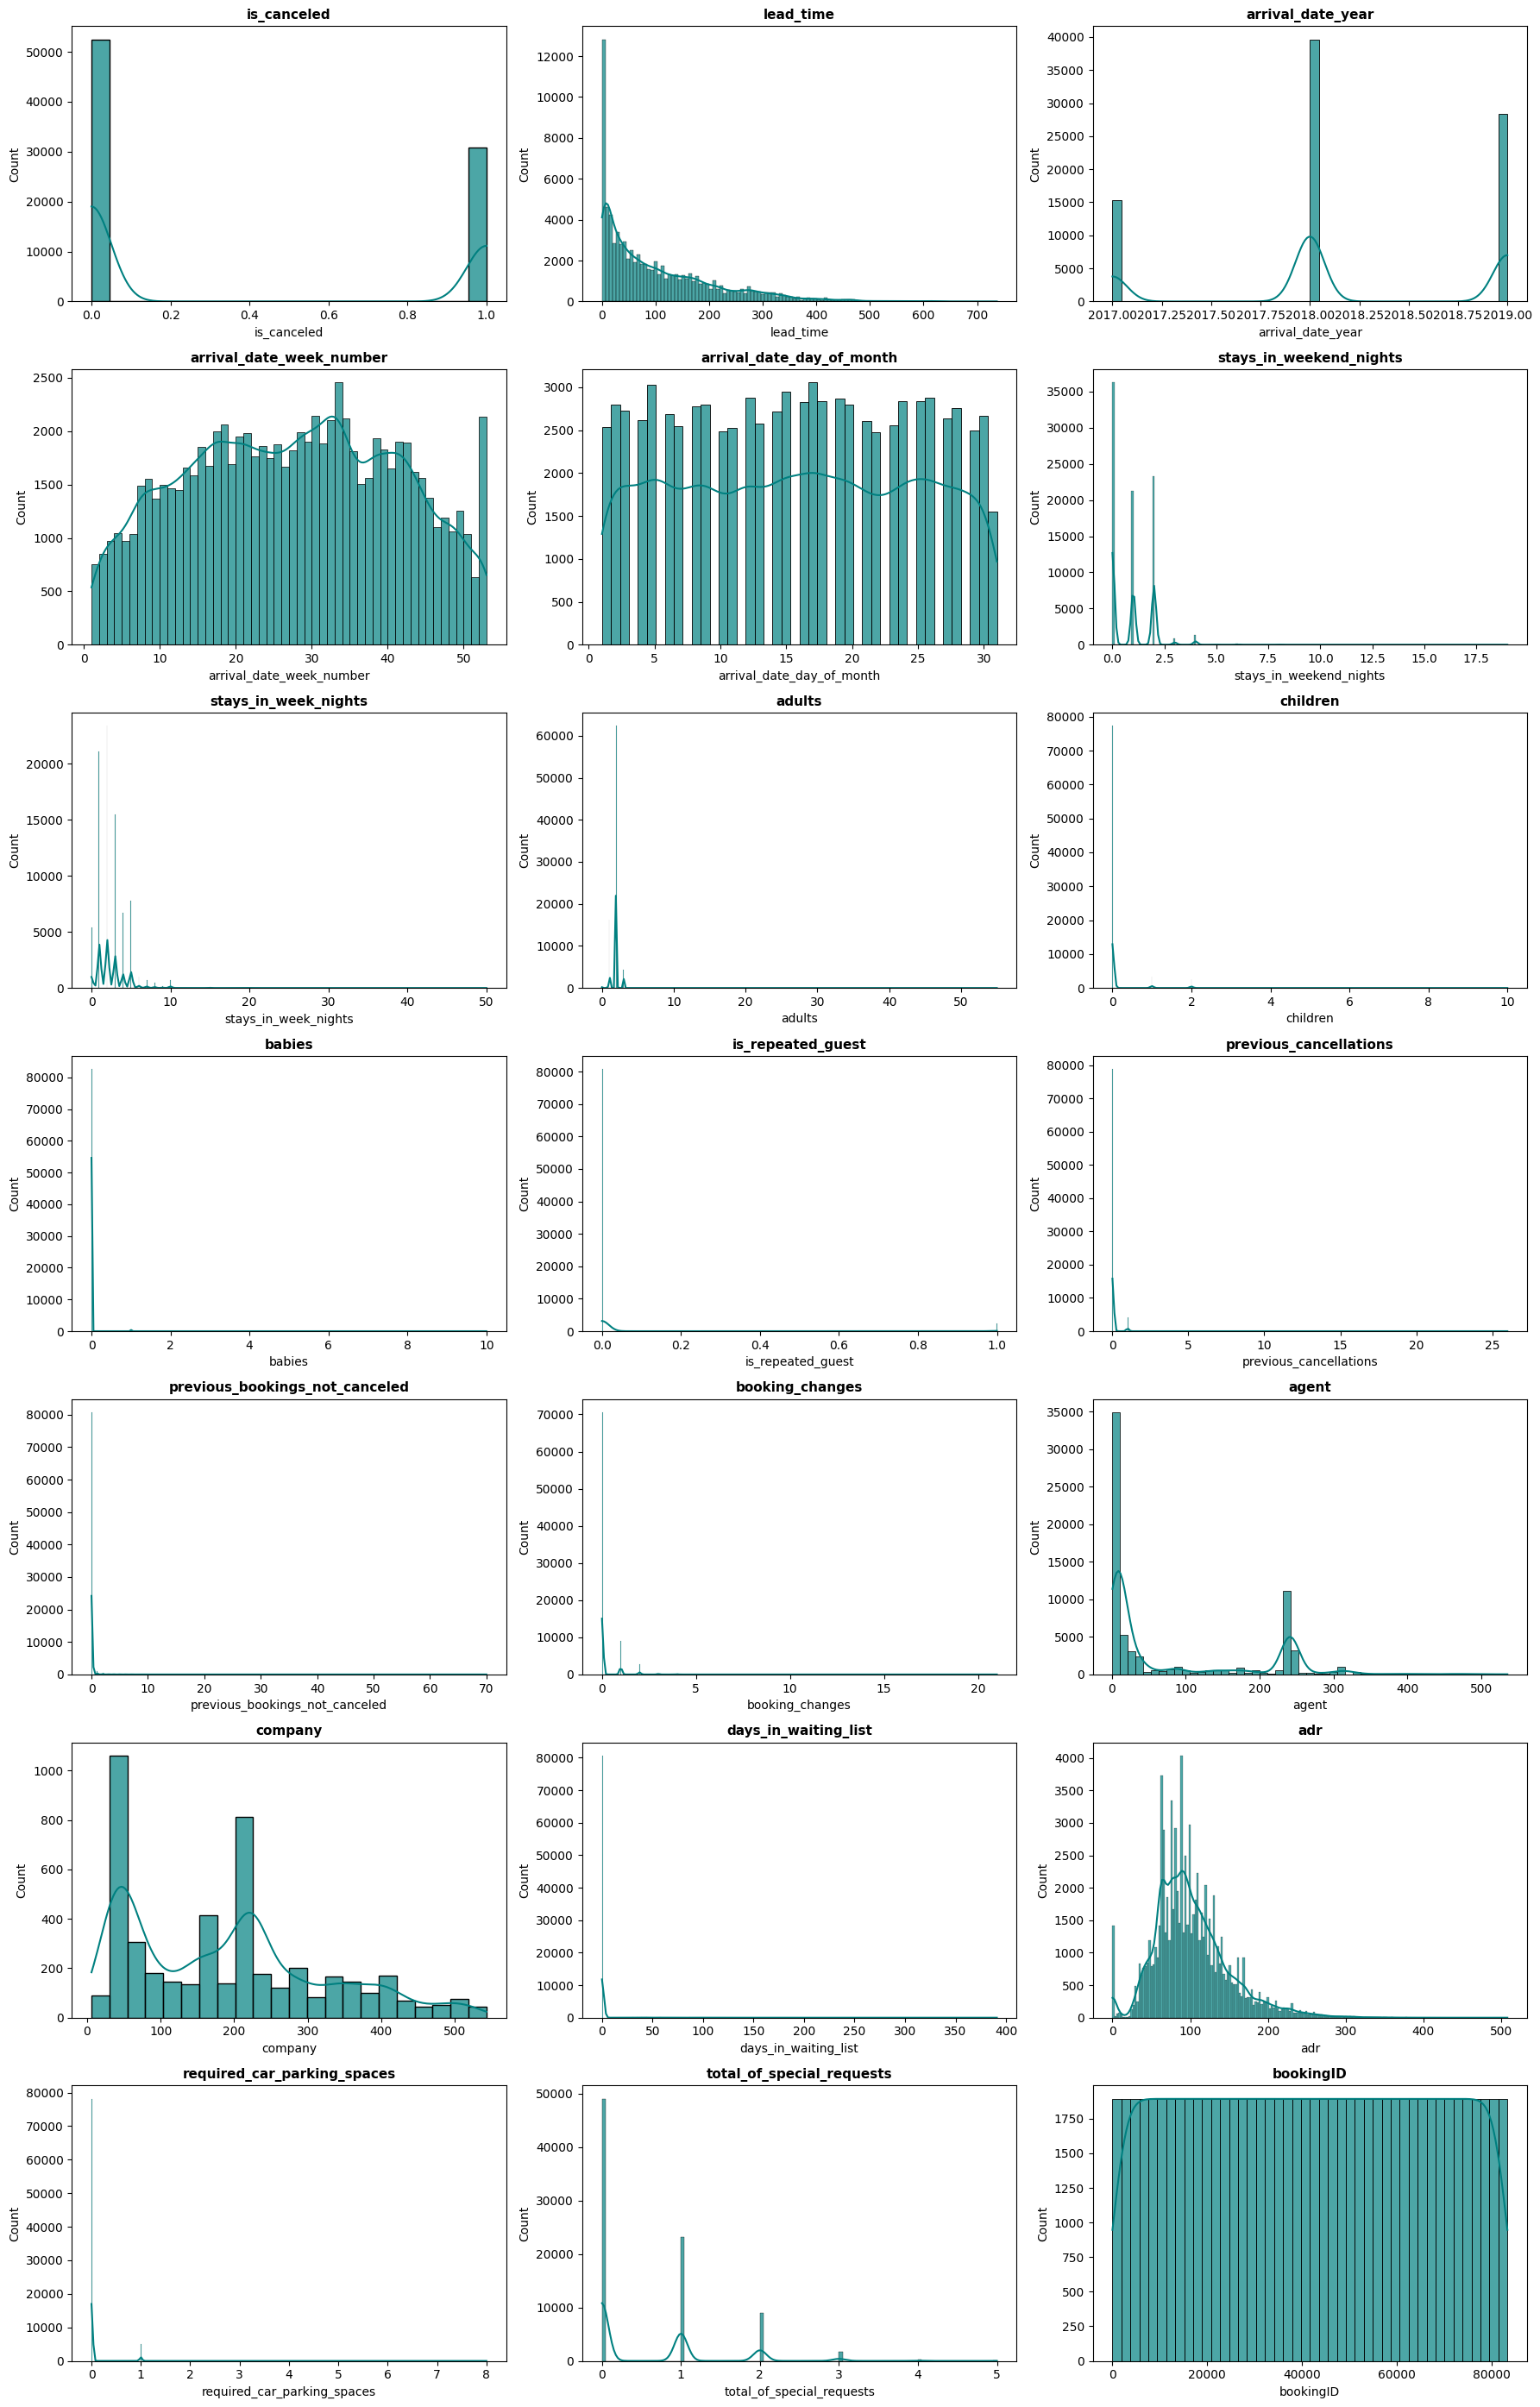

In [735]:
# Distribution Visual

numeric_cols = df.select_dtypes(include=np.number).columns

cols = 3  # jumlah kolom horizontal
rows = math.ceil(len(numeric_cols) / cols)

plt.figure(figsize=(18, 4*rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    
    sns.histplot(
        df[col].dropna(),
        kde=True,
        color='teal',
        edgecolor='black',
        alpha=0.7
    )
    
    plt.title(col, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Data Cleaning

In [736]:
df_clean = df.copy()

## Missing Value

In [737]:
# Display unique values in the 'company' column
df['company'].unique()

array([ nan, 200., 424., 219.,  40.,  47., 195., 179.,  45., 477.,  43.,
       169., 380., 281., 135., 498., 223., 405.,  51., 218.,  91., 204.,
       242.,  67., 307.,  35., 153., 207., 409., 403., 331.,  94., 366.,
       251., 163., 394.,  20., 227., 209., 481., 202., 292., 154., 238.,
       395., 348., 347., 270., 507.,  34., 178., 400.,  14., 379., 333.,
       174., 148.,  68., 396.,  72., 110., 274.,  46., 523., 342., 143.,
       215., 448., 193., 269.,  84., 410., 233.,  59., 122., 513., 418.,
       341., 496., 280., 485., 343.,  78., 478.,  82., 421., 419.,  92.,
       399., 286., 291., 437., 221.,  38., 445., 420., 426.,  86., 325.,
       113., 127., 511., 487., 118., 146., 282.,  37., 144., 465., 385.,
       338., 530., 350., 105., 268.,  88., 382., 428., 184., 323., 142.,
       159., 358.,   9., 245., 439., 452., 392., 287., 225., 386., 203.,
        42.,  12., 301., 290., 275., 213., 103., 388., 302., 337., 442.,
       264., 312., 130., 216., 402., 435., 106., 11

In [738]:
# Fill missing values in the 'company' column with 0
df_clean['company'] = df_clean['company'].fillna(0)

In [739]:
# Check unique values in the 'agent' column
df['agent'].unique()

array([314.,   1.,  12.,  nan,  16.,   9.,  14.,  27., 240., 250., 241.,
       492., 184., 251.,   7., 170.,  11., 115., 394., 243.,  40.,   6.,
        19.,  15.,  21., 440., 196., 195.,  36.,  30.,  83., 296.,  56.,
       177., 147., 155., 146., 229., 298.,  10.,  37.,  79., 142.,  96.,
       168.,  28., 286., 388.,  26., 468.,  69., 236., 273.,   8., 287.,
        17., 153.,  22., 156.,   3., 171.,  29.,  58., 281., 132., 143.,
       134., 192.,  20.,  71., 315., 242., 234.,  87.,  42., 455., 215.,
       495.,  86.,  35., 337., 245., 248.,  63.,  95.,   5., 308., 326.,
        82., 220., 119., 191.,  52., 193., 410.,  38.,  89.,  34., 152.,
        41., 138., 306., 330.,  67.,  44., 157.,  75., 364., 159., 467.,
       479., 339., 253.,  85.,  78., 531., 332.,  68., 181., 327., 112.,
       254., 434., 235., 305., 126., 163., 464.,   2., 223.,  31.,  64.,
        47., 118., 174., 378., 249., 261., 127., 154., 175., 290., 405.,
       208.,  24.,  94.,  33.,  32., 336., 425., 21

In [740]:
# Check if 0 exists in the unique values of the 'agent' column
if 0 in df['agent'].unique():
    print('0 exists')
else:
    print('0 does not exist')

0 does not exist


In [741]:
# Fill missing values in the 'agent' column with 0
df_clean['agent'] = df_clean['agent'].fillna(0)

df_clean['agent'].unique()

array([314.,   1.,  12.,   0.,  16.,   9.,  14.,  27., 240., 250., 241.,
       492., 184., 251.,   7., 170.,  11., 115., 394., 243.,  40.,   6.,
        19.,  15.,  21., 440., 196., 195.,  36.,  30.,  83., 296.,  56.,
       177., 147., 155., 146., 229., 298.,  10.,  37.,  79., 142.,  96.,
       168.,  28., 286., 388.,  26., 468.,  69., 236., 273.,   8., 287.,
        17., 153.,  22., 156.,   3., 171.,  29.,  58., 281., 132., 143.,
       134., 192.,  20.,  71., 315., 242., 234.,  87.,  42., 455., 215.,
       495.,  86.,  35., 337., 245., 248.,  63.,  95.,   5., 308., 326.,
        82., 220., 119., 191.,  52., 193., 410.,  38.,  89.,  34., 152.,
        41., 138., 306., 330.,  67.,  44., 157.,  75., 364., 159., 467.,
       479., 339., 253.,  85.,  78., 531., 332.,  68., 181., 327., 112.,
       254., 434., 235., 305., 126., 163., 464.,   2., 223.,  31.,  64.,
        47., 118., 174., 378., 249., 261., 127., 154., 175., 290., 405.,
       208.,  24.,  94.,  33.,  32., 336., 425., 21

In [742]:
# cek column country
df['country'].unique()

array(['ITA', 'PRT', nan, 'BEL', 'DNK', 'GBR', 'IRL', 'ESP', 'DEU', 'RUS',
       'NOR', 'CN', 'USA', 'AUS', 'CHE', 'NLD', 'FRA', 'CHN', 'TUR',
       'BRA', 'KOR', 'PLW', 'ZAF', 'POL', 'HUN', 'MOZ', 'HKG', 'IND',
       'LUX', 'MAR', 'FIN', 'ISR', 'DZA', 'SWE', 'CYP', 'GRC', 'OMN',
       'AUT', 'JPN', 'SVN', 'AGO', 'MCO', 'ARG', 'MYS', 'LVA', 'LTU',
       'MEX', 'STP', 'SAU', 'MRT', 'NGA', 'SVK', 'COL', 'THA', 'ROU',
       'SUR', 'BGR', 'EST', 'ARE', 'VEN', 'SGP', 'BIH', 'CHL', 'HRV',
       'URY', 'TWN', 'ALB', 'GNB', 'BLR', 'SRB', 'GEO', 'CUB', 'CZE',
       'ZMB', 'ZWE', 'BHR', 'KEN', 'IRN', 'PER', 'ISL', 'TJK', 'LBN',
       'NZL', 'MAC', 'SEN', 'PHL', 'JOR', 'AND', 'DJI', 'KAZ', 'GTM',
       'IRQ', 'GAB', 'LBY', 'MDV', 'TUN', 'EGY', 'UKR', 'GIB', 'PRY',
       'KWT', 'KNA', 'IDN', 'CPV', 'GLP', 'COM', 'AZE', 'UGA', 'MKD',
       'LAO', 'SYC', 'MLT', 'PAK', 'QAT', 'AIA', 'FJI', 'DOM', 'ECU',
       'PRI', 'CRI', 'CAF', 'MMR', 'ARM', 'SLV', 'TZA', 'HND', 'BEN',
       'KHM', 'F

In [743]:
# Replace NaN values in the 'country' column with 'UNK'
df_clean['country'] = df_clean['country'].replace(np.nan, 'unknown')

# Display unique values in the 'country' column
df_clean['country'].unique()

array(['ITA', 'PRT', 'unknown', 'BEL', 'DNK', 'GBR', 'IRL', 'ESP', 'DEU',
       'RUS', 'NOR', 'CN', 'USA', 'AUS', 'CHE', 'NLD', 'FRA', 'CHN',
       'TUR', 'BRA', 'KOR', 'PLW', 'ZAF', 'POL', 'HUN', 'MOZ', 'HKG',
       'IND', 'LUX', 'MAR', 'FIN', 'ISR', 'DZA', 'SWE', 'CYP', 'GRC',
       'OMN', 'AUT', 'JPN', 'SVN', 'AGO', 'MCO', 'ARG', 'MYS', 'LVA',
       'LTU', 'MEX', 'STP', 'SAU', 'MRT', 'NGA', 'SVK', 'COL', 'THA',
       'ROU', 'SUR', 'BGR', 'EST', 'ARE', 'VEN', 'SGP', 'BIH', 'CHL',
       'HRV', 'URY', 'TWN', 'ALB', 'GNB', 'BLR', 'SRB', 'GEO', 'CUB',
       'CZE', 'ZMB', 'ZWE', 'BHR', 'KEN', 'IRN', 'PER', 'ISL', 'TJK',
       'LBN', 'NZL', 'MAC', 'SEN', 'PHL', 'JOR', 'AND', 'DJI', 'KAZ',
       'GTM', 'IRQ', 'GAB', 'LBY', 'MDV', 'TUN', 'EGY', 'UKR', 'GIB',
       'PRY', 'KWT', 'KNA', 'IDN', 'CPV', 'GLP', 'COM', 'AZE', 'UGA',
       'MKD', 'LAO', 'SYC', 'MLT', 'PAK', 'QAT', 'AIA', 'FJI', 'DOM',
       'ECU', 'PRI', 'CRI', 'CAF', 'MMR', 'ARM', 'SLV', 'TZA', 'HND',
       'BEN', 'KH

In [744]:
# CN and CHN represent the same country (China), so unify them to the same value
df_clean['country'] = df_clean['country'].replace('CN', 'CHN')

# Display unique values in the 'country' column
df_clean['country'].unique()

array(['ITA', 'PRT', 'unknown', 'BEL', 'DNK', 'GBR', 'IRL', 'ESP', 'DEU',
       'RUS', 'NOR', 'CHN', 'USA', 'AUS', 'CHE', 'NLD', 'FRA', 'TUR',
       'BRA', 'KOR', 'PLW', 'ZAF', 'POL', 'HUN', 'MOZ', 'HKG', 'IND',
       'LUX', 'MAR', 'FIN', 'ISR', 'DZA', 'SWE', 'CYP', 'GRC', 'OMN',
       'AUT', 'JPN', 'SVN', 'AGO', 'MCO', 'ARG', 'MYS', 'LVA', 'LTU',
       'MEX', 'STP', 'SAU', 'MRT', 'NGA', 'SVK', 'COL', 'THA', 'ROU',
       'SUR', 'BGR', 'EST', 'ARE', 'VEN', 'SGP', 'BIH', 'CHL', 'HRV',
       'URY', 'TWN', 'ALB', 'GNB', 'BLR', 'SRB', 'GEO', 'CUB', 'CZE',
       'ZMB', 'ZWE', 'BHR', 'KEN', 'IRN', 'PER', 'ISL', 'TJK', 'LBN',
       'NZL', 'MAC', 'SEN', 'PHL', 'JOR', 'AND', 'DJI', 'KAZ', 'GTM',
       'IRQ', 'GAB', 'LBY', 'MDV', 'TUN', 'EGY', 'UKR', 'GIB', 'PRY',
       'KWT', 'KNA', 'IDN', 'CPV', 'GLP', 'COM', 'AZE', 'UGA', 'MKD',
       'LAO', 'SYC', 'MLT', 'PAK', 'QAT', 'AIA', 'FJI', 'DOM', 'ECU',
       'PRI', 'CRI', 'CAF', 'MMR', 'ARM', 'SLV', 'TZA', 'HND', 'BEN',
       'KHM', 'F

In [745]:
# Check rows where 'children' column has missing values
df.loc[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
6592,"Renaissance Hamburg Hotel Hamburg, Germany",1,1,2017,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2017-08-04,6593
24197,Protea Hotel Fire & Ice! by Marriott Johannesb...,1,8,2017,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2017-08-09,24198
75373,"Colony Club, Barbados Barbados",1,1,2017,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2017-08-04,75374


In [746]:
# Filling the missing values in 'children' column with 0 seems reasonable
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

# Display unique values in the 'children' column
df_clean['children'].unique()

array([ 0,  1,  2,  3, 10])

In [747]:
print(df_clean['children'].copy().unique())

# Check the shape of the DataFrame
df.shape

[ 0  1  2  3 10]


(83293, 33)

## Cek Inkonsistensi Data

In [748]:
# Check data for each column
for col in df_clean.columns:
    print(f'{col} :\n{df_clean[col].unique()}\n')

hotel :
['Crystal Cove, Barbados Barbados' 'Greensboro Courtyard Greensboro, NC'
 'The Westin Peachtree Plaza, Atlanta Atlanta, GA '
 'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom'
 'W New York – Union Square New York, NY'
 'Hotel Maria Cristina, San Sebastian San Sebastian, Spain'
 'W New York – Times Square New York, NY'
 'The Ritz-Carlton, Tokyo Tokyo, Japan'
 'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico'
 'Las Vegas Marriott Las Vegas, NV '
 'Heidelberg Marriott Hotel Heidelberg, Germany'
 'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil'
 'Renaissance Hamburg Hotel Hamburg, Germany'
 'The Ritz-Carlton, Berlin Berlin, Germany'
 'Sheraton Lima Hotel & Convention Center Lima, Peru'
 'Courtyard Las Vegas Convention Center Las Vegas, NV '
 'Newark Liberty International Airport Courtyard Newark, NJ'
 'Indianapolis Airport Courtyard Indianapolis, IN'
 'Treasure Beach, Barbados Barbados'
 'Cape Town Marriott Hotel Crystal Towers Cape Town, Sou

In [749]:
# Convert 'company' and 'agent' columns to integer type
df_clean['company'] = df_clean['company'].astype(int)
df_clean['agent'] = df_clean['agent'].astype(int)

In [750]:
# convert reservation status to datetime
df_clean['reservation_status_date']= pd.to_datetime(df_clean['reservation_status_date'])

In [751]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           83293 non-null  object        
 1   is_canceled                     83293 non-null  int64         
 2   lead_time                       83293 non-null  int64         
 3   arrival_date_year               83293 non-null  int64         
 4   arrival_date_month              83293 non-null  object        
 5   arrival_date_week_number        83293 non-null  int64         
 6   arrival_date_day_of_month       83293 non-null  int64         
 7   stays_in_weekend_nights         83293 non-null  int64         
 8   stays_in_week_nights            83293 non-null  int64         
 9   adults                          83293 non-null  int64         
 10  children                        83293 non-null  int64         
 11  ba

## Cek outlier

In [752]:
# Memeriksa Outlier
num_cols = df.select_dtypes(include="number").columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df[num_cols] < lower) | (df[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df[num_cols] < lower) | (df[num_cols] > upper)).sum() / len(df) * 100
    ).round(2),
    "Nilai Skewness": df[num_cols].skew()
})

outlier_summary

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
is_canceled,0,0.00,0.540740
lead_time,2112,2.54,1.356006
arrival_date_year,0,0.00,-0.232262
arrival_date_week_number,0,0.00,-0.010823
arrival_date_day_of_month,0,0.00,-0.000168
stays_in_weekend_nights,196,0.24,1.446361
stays_in_week_nights,2355,2.83,2.982342
adults,20920,25.12,21.846692
children,5961,7.16,4.160475
babies,643,0.77,28.416932


### Handling outlier

In [753]:
# Check for cases with no people in the booking
no_adults = df_clean['adults'] == 0  # Check if the number of adults is 0
no_children = df_clean['children'] == 0  # Check if the number of children is 0
no_babies = df_clean['babies'] == 0  # Check if the number of babies is 0
no_people = no_adults & no_children & no_babies  # Identify rows where there are no adults, children, or babies

df_clean[no_people].shape  # Output the number of such rows

(127, 33)

In [754]:
# Remove rows where there are no people in the booking
df_clean = df_clean[~no_people]  # Exclude rows where all counts (adults, children, babies) are 0

df_clean.shape  # Output the new shape of the DataFrame

(83166, 33)

In [755]:
# Group rows where there are no adults by the number of children, babies, and reservation status

# Filter rows where there are no adults
no_adult = df_clean[no_adults]

# Group by 'children', 'babies', and 'reservation_status'
# Display the size of each group in a pivot-table-like structure
no_adult.groupby(['children', 'babies', 'reservation_status']).size().unstack(['children', 'babies'])

/var/folders/1k/sdmmxldn72x7m1dp7r9vnbg80000gn/T/ipykernel_1686/1961500413.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  no_adult = df_clean[no_adults]


children              1     2         3
babies                0     0    1    0
reservation_status                     
Canceled            NaN  55.0  NaN  2.0
Check-Out           3.0  91.0  1.0  6.0
No-Show             NaN   2.0  NaN  NaN

In [756]:
# Remove rows where there are no adults in the booking

# Use the ~ operator to invert the condition and keep rows where there are adults
df_clean = df_clean[~no_adults]

# Check the shape of the dataset after removal
df_clean.shape

/var/folders/1k/sdmmxldn72x7m1dp7r9vnbg80000gn/T/ipykernel_1686/3393146205.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[~no_adults]


(83006, 33)

In [757]:
# Filter rows where the required number of car parking spaces exceeds 3
df_clean[df_clean['required_car_parking_spaces'] > 3]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
3956,Protea Hotel Fire & Ice! by Marriott Johannesb...,0,138,2019,March,12,19,2,2,2,0,0,HB,AUT,Direct,Corporate,1,0,2,E,F,1,No Deposit,0,0,122,Transient-Party,80.0,8,0,Check-Out,2019-03-23,3957
46574,Irvine John Wayne Airport/Orange County Courty...,0,26,2019,March,11,14,0,5,2,0,0,HB,AUT,Direct,Corporate,1,0,2,E,I,1,No Deposit,0,0,0,Transient-Party,40.0,8,1,Check-Out,2019-03-19,46575


In [758]:
# Remove rows where the required car parking spaces exceed 3

# Filter rows where 'required_car_parking_spaces' is less than or equal to 3
df_clean = df_clean[df_clean['required_car_parking_spaces'] <= 3]

# Check the shape of the dataset after removal
df_clean.shape

(83004, 33)

In [759]:
# Set conditions for filtering data
book_cancel = df_clean['previous_cancellations'] == 0  # No previous cancellations
book_not_cancel = df_clean['previous_bookings_not_canceled'] == 0  # No previous non-cancellations
repeat_guest = df_clean['is_repeated_guest'] == 0  # Guest has not visited before

# Filter rows where there are no cancellation/non-cancellation experiences but the guest has visited before
filtered_data = df_clean[book_cancel & book_not_cancel & ~repeat_guest]

# Display the shape of the filtered dataset
filtered_data.shape

(361, 33)

In [760]:
# Filter rows where there is a cancellation or non-cancellation experience but the guest has never visited

# Condition: Guests with cancellation or non-cancellation experience and no repeated visits
filtered_data = df_clean[~book_cancel & ~book_not_cancel & repeat_guest]

# Display the shape of the filtered dataset
filtered_data.shape


(76, 33)

In [761]:
def cap_outliers(df, col):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean[col] = np.where(df_clean[col] > upper, upper,
                       np.where(df_clean[col] < lower, lower, df_clean[col]))
    return df_clean

cols = ['lead_time', 'adr', 'stays_in_week_nights', 'booking_changes']

for col in cols:
    df_clean = cap_outliers(df_clean, col)

In [762]:
df_clean.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,bookingID
count,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.0,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004.000000,83004,83004.000000
mean,0.369886,102.158209,2018.156595,27.162113,15.783890,0.929835,2.407017,1.860874,0.100055,0.008048,0.029842,0.087237,0.141981,0.0,75.165004,10.776131,2.354019,100.734287,0.061768,0.571165,2018-07-30 14:40:58.638137856,41651.794757
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017-01-01 00:00:00,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,7.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2018-02-01 00:00:00,20832.750000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,9.000000,0.000000,0.000000,94.965000,0.000000,0.000000,2018-08-06 00:00:00,41653.500000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,154.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2019-02-07 00:00:00,62474.250000
max,1.000000,373.000000,2019.000000,53.000000,31.000000,19.000000,6.000000,55.000000,10.000000,10.000000,1.000000,26.000000,70.000000,0.0,535.000000,543.000000,391.000000,210.000000,3.000000,5.000000,2019-09-10 00:00:00,83293.000000
std,0.482776,101.093525,0.706894,13.616494,8.776222,1.001808,1.530203,0.597286,0.390236,0.100756,0.170152,0.864432,1.556597,0.0,107.340331,54.019492,17.832448,44.415210,0.242182,0.793260,NaN,24041.730440


In [763]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83290.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,71889.000000,4734.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,2018.156808,27.164023,15.786116,0.930390,2.503812,1.854466,0.103614,0.008032,0.030243,0.086994,0.141765,0.223068,86.867282,190.003802,2.352238,101.724373,0.061818,0.571945,41647.000000
std,0.482673,106.874124,0.706656,13.623752,8.775931,1.004196,1.924511,0.606139,0.398821,0.100641,0.171255,0.862988,1.554390,0.656237,110.875605,131.969152,17.820652,48.082552,0.245027,0.793742,24044.762323
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,183.000000,0.000000,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,70.000000,21.000000,535.000000,543.000000,391.000000,508.000000,8.000000,5.000000,83293.000000


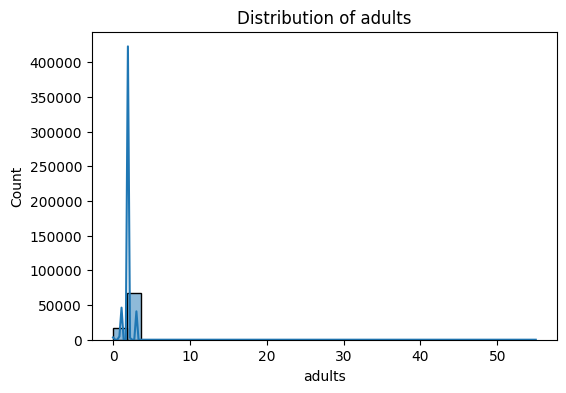

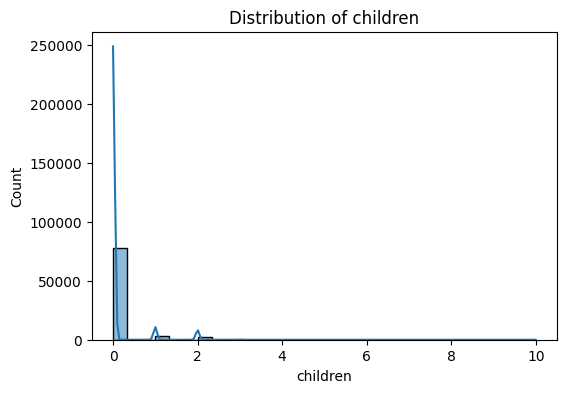

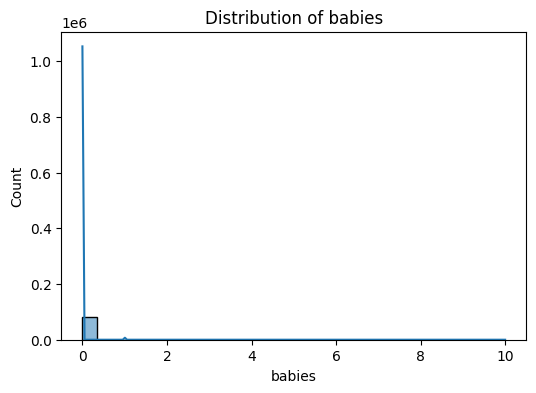

In [764]:
cols = ['adults', 'children', 'babies']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [765]:
# remove yang punya babies lebih dari 5 
df_clean = df_clean[df_clean['babies'] <= 5]
df_clean.shape

(83002, 33)

### After Handling Outlier

In [766]:
# Outlier setelah dibersihkan
num_cols = df_clean.select_dtypes(include="number").columns

Q1 = df_clean[num_cols].quantile(0.25)
Q3 = df_clean[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df_clean[num_cols] < lower) | (df_clean[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df_clean[num_cols] < lower) | (df_clean[num_cols] > upper)).sum() / len(df_clean) * 100
    ).round(2),
    "Nilai Skewness": df_clean[num_cols].skew()
})

outlier_summary

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
is_canceled,0,0.00,0.538998
lead_time,0,0.00,1.060150
arrival_date_year,0,0.00,-0.232153
arrival_date_week_number,0,0.00,-0.011190
arrival_date_day_of_month,0,0.00,-0.000082
stays_in_weekend_nights,191,0.23,1.416750
stays_in_week_nights,0,0.00,0.628458
adults,20632,24.86,22.983967
children,5801,6.99,4.237920
babies,640,0.77,11.629717


# EDA

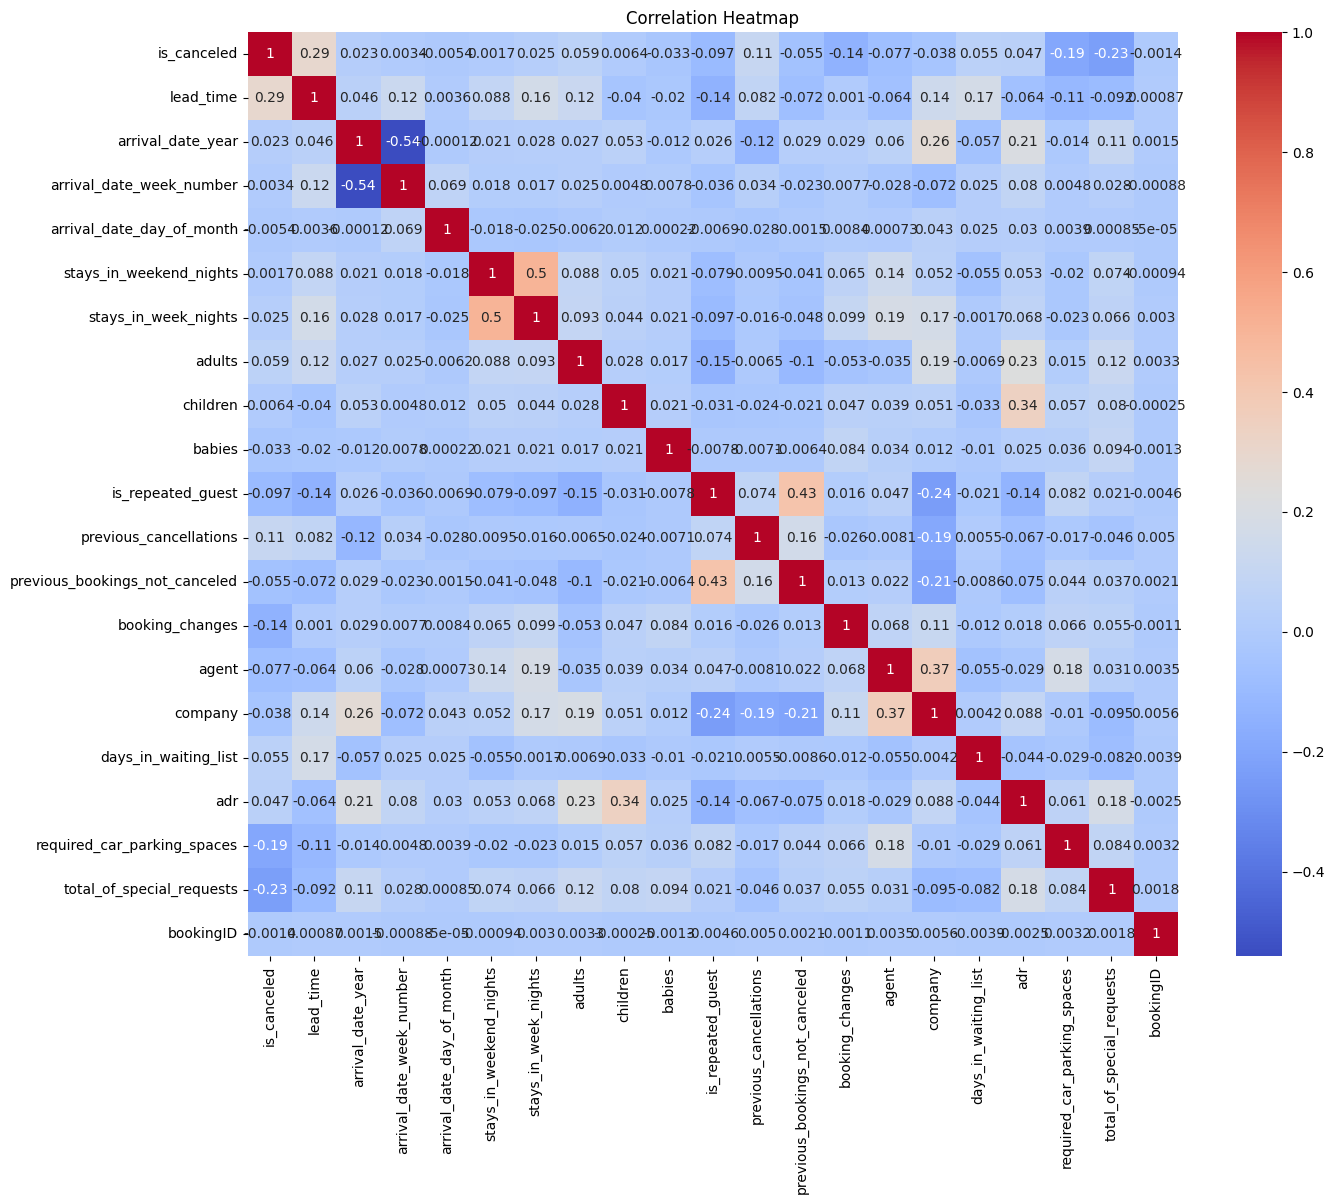

In [767]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

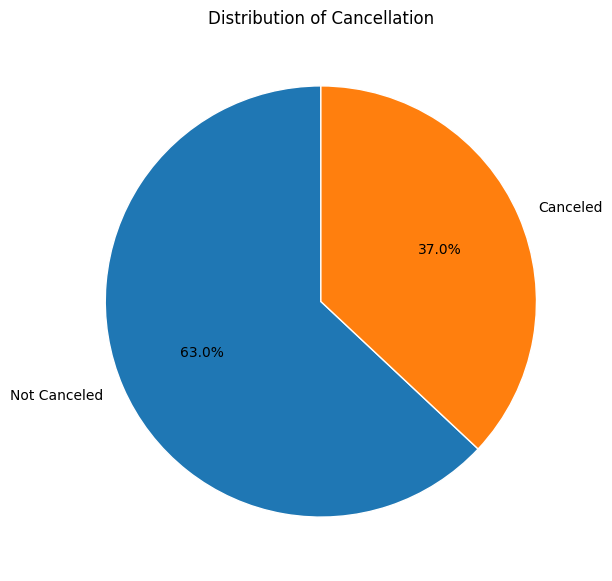

In [768]:
# Hitung jumlah cancel vs not cancel
counts = df_clean['is_canceled'].value_counts().sort_index()

# Label biar lebih jelas
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(7,7))
plt.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribution of Cancellation')
plt.show()

According to the pie chart, 63% of bookings were not canceled and 37% of the bookings were canceled at the Hotel.

Text(0.5, 1.0, 'Arriving year, Lead time and Cancelations')

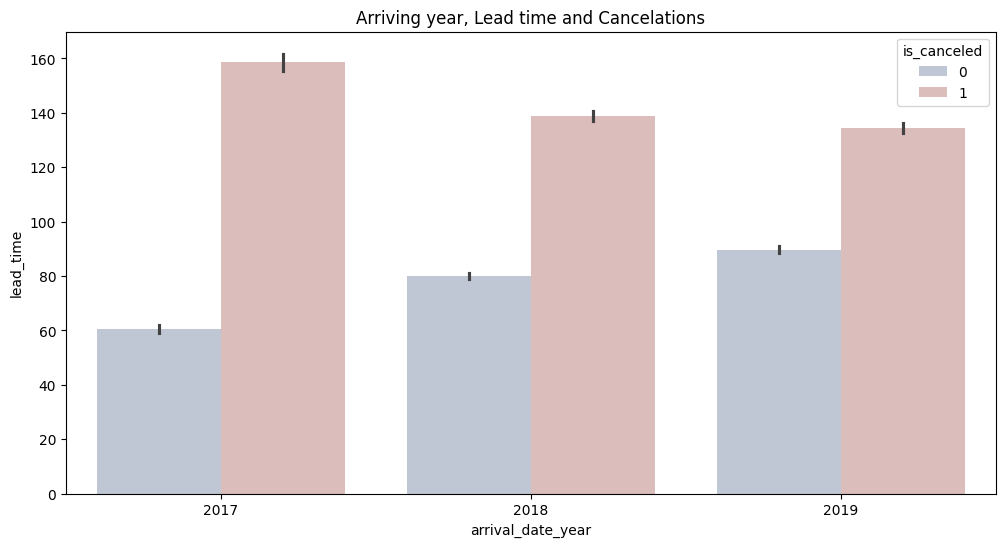

In [769]:
plt.figure(figsize=(12,6))
sns.barplot(x='arrival_date_year', y='lead_time',hue='is_canceled', data= df_clean, palette='vlag')
plt.title('Arriving year, Lead time and Cancelations')

**Interpretation:**
The bar chart compares the average lead time between canceled and non-canceled bookings across different years.

- In **2017**:
  - Canceled bookings ≈ 160 days
  - Non-canceled bookings ≈ 60 days
- In **2018**:
  - Canceled ≈ 140 days
  - Non-canceled ≈ 80 days
- In **2019**:
  - Canceled ≈ 135 days
  - Non-canceled ≈ 90 days

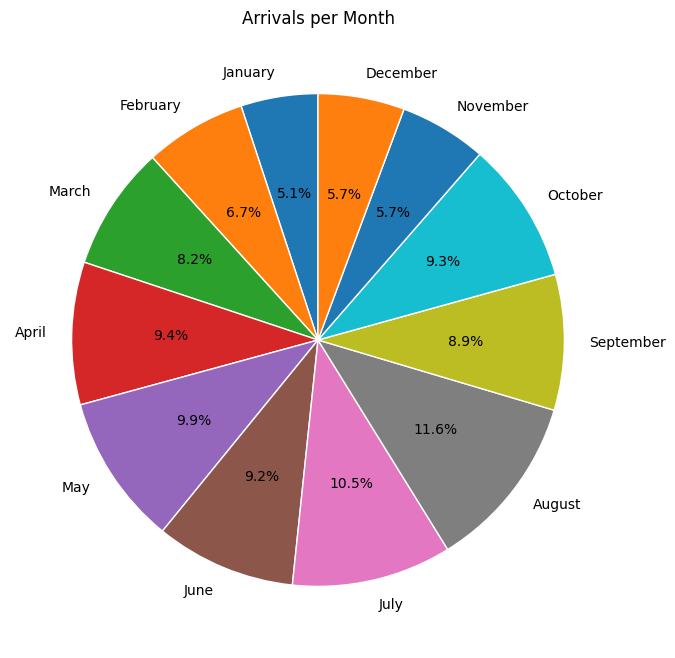

In [788]:
# Urutan bulan yang benar
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# Hitung jumlah booking per bulan
counts = (
    df_clean['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(8,8))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Arrivals per Month')
plt.show()

**Interpretation:**
The pie chart shows the distribution of hotel arrivals across each month, highlighting seasonal demand patterns.

- The highest arrivals occur in:
  - **August (11.6%)**
  - **July (10.5%)**
  - **May (9.9%)**
- Moderate demand is observed in April, June, September, and October.
- The lowest arrivals occur in:
  - **January (5.1%)**
  - **November (5.7%)**
  - **December (5.7%)**


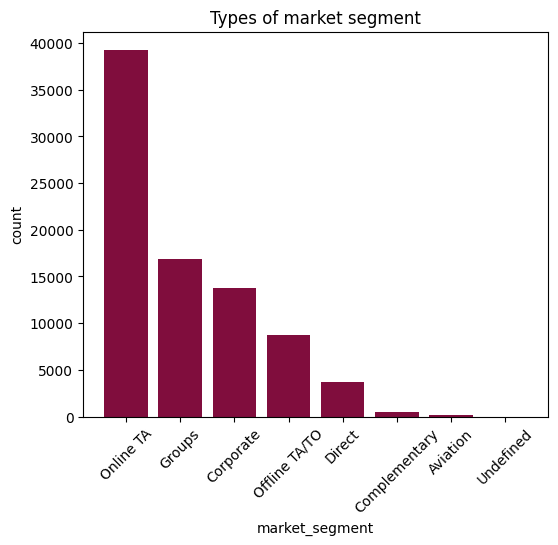

In [789]:
labels = df_clean['market_segment'].unique()
values = df_clean['market_segment'].value_counts()
plt.figure(figsize=(6,5))
plt.title('Types of market segment')
plt.bar(labels,values,color='#800d3d')
plt.xticks(rotation=45)
plt.xlabel('market_segment')
plt.ylabel('count')
plt.show()

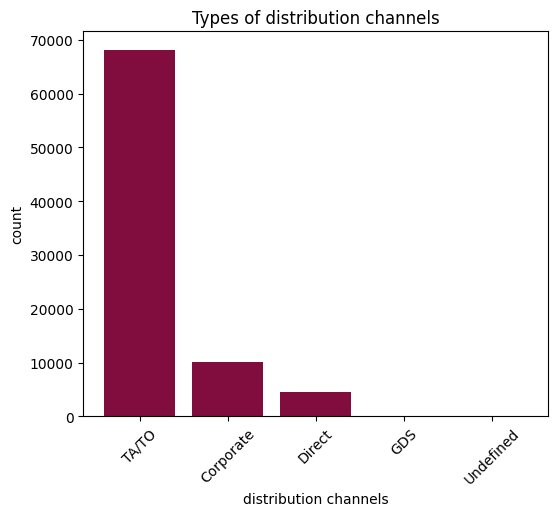

In [772]:
labels = df_clean['distribution_channel'].unique()
values = df_clean['distribution_channel'].value_counts()
plt.figure(figsize=(6,5))
plt.title('Types of distribution channels')
plt.bar(labels,values,color='#800d3d')
plt.xticks(rotation=45)
plt.xlabel('distribution channels')
plt.ylabel('count')
plt.show()

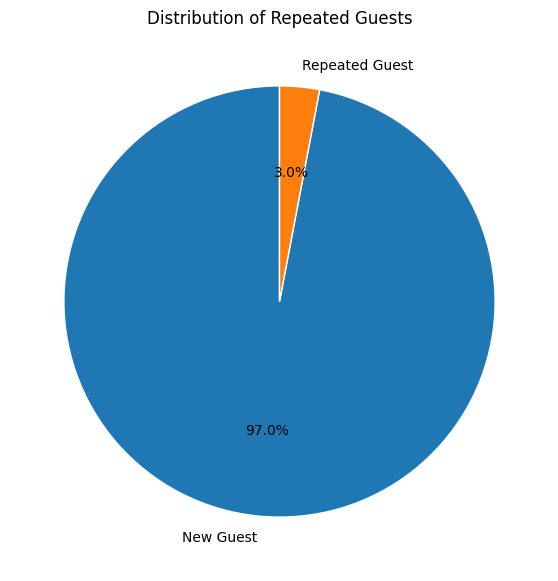

In [773]:
# Hitung jumlah
counts = df_clean['is_repeated_guest'].value_counts()

# Mapping label biar lebih jelas
labels = ['New Guest', 'Repeated Guest']

plt.figure(figsize=(7,7))
plt.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribution of Repeated Guests')
plt.show()

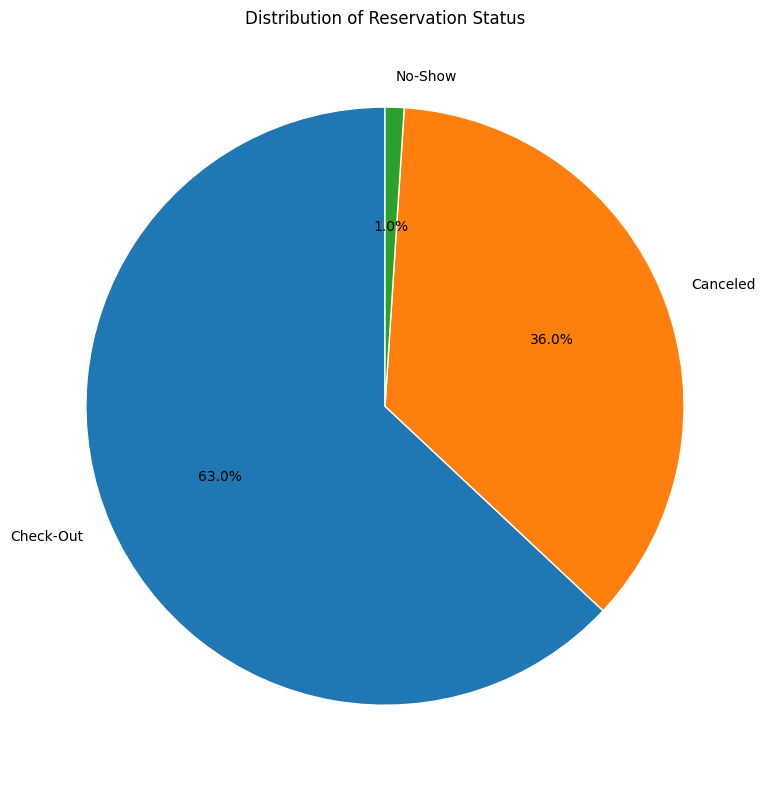

In [787]:
status_counts = df_clean['reservation_status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribution of Reservation Status')
plt.tight_layout()
plt.show()

**Interpretation:**
The pie chart shows the overall distribution of reservation outcomes.

- **Check-Out:** 63.0% → Majority of bookings are successfully completed  
- **Canceled:** 36.0% → A significant portion of bookings are canceled  
- **No-Show:** 1.0% → Very small proportion of guests do not show up  

**Key Insight:**
While most bookings result in successful stays, the cancellation rate is relatively high.

**Business Insight:**
A 36% cancellation rate indicates potential inefficiencies in booking commitment. This suggests the need for improved cancellation policies, such as deposits or stricter deadlines.

According to the pie chart, 63% of bookings were not canceled and 36% of the bookings were canceled at the Hotel.

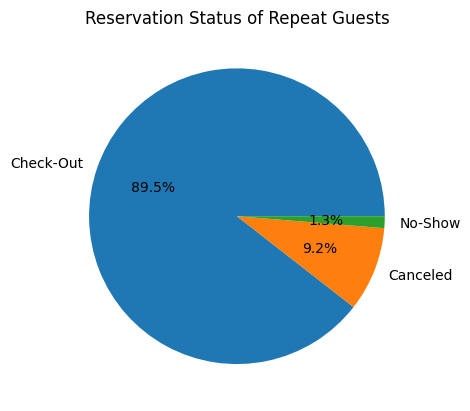

In [775]:
repeat = df_clean[df_clean['is_repeated_guest'] == 1]

status_counts = repeat['reservation_status'].value_counts()

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title('Reservation Status of Repeat Guests')
plt.show()

**Interpretation:**
This chart focuses on returning (repeat) guests and their booking outcomes.

- **Check-Out:** 89.5% → Vast majority of repeat guests complete their stay  
- **Canceled:** 9.2% → Significantly lower cancellation rate  
- **No-Show:** 1.3% → Minimal no-show behavior  

**Key Insight:**
Repeat guests are far more reliable compared to overall customers.

**Important Pattern:**
- Cancellation rate drops significantly from **36% (overall)** to **9.2% (repeat guests)**

**Business Insight:**
Repeat guests demonstrate strong loyalty and lower cancellation risk, making them highly valuable. Hotels should focus on retention strategies such as loyalty programs, personalized offers, and targeted marketing.


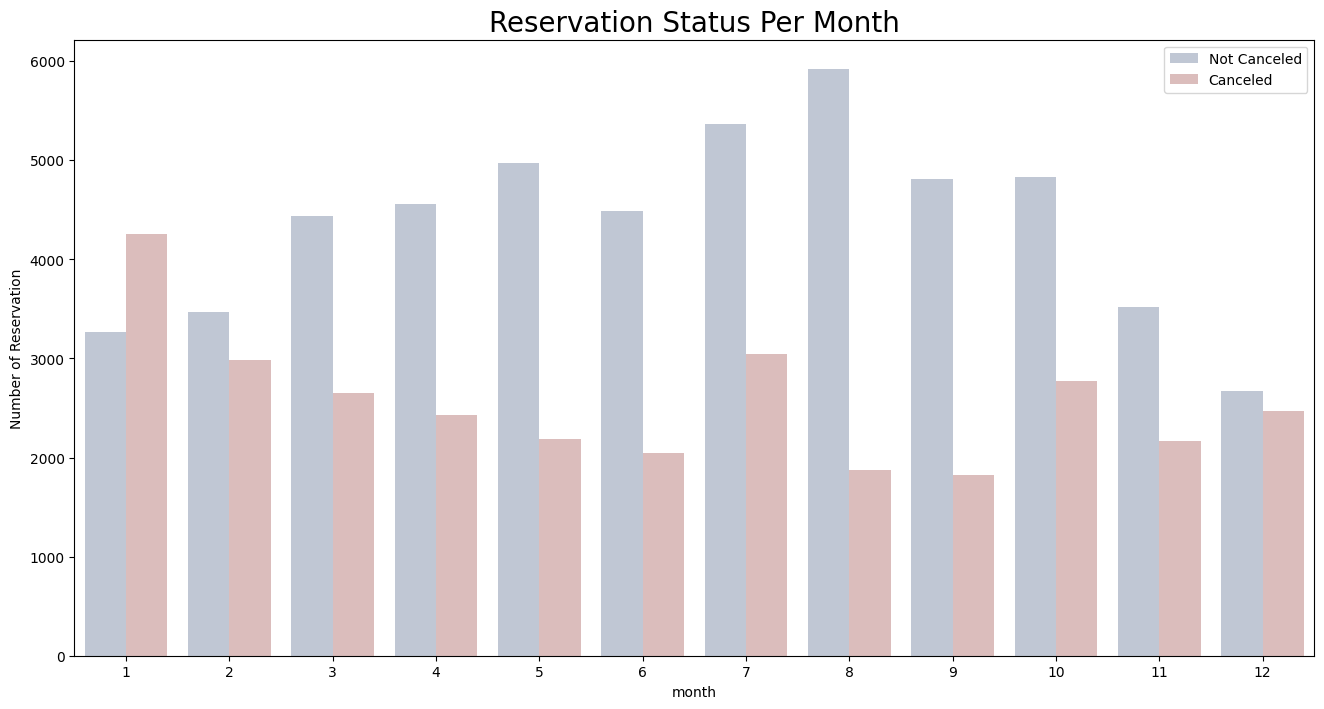

In [776]:
df_clean['month']=df_clean['reservation_status_date'].dt.month
plt.figure(figsize=(16,8))
ax1 = sns.countplot(x='month', hue='is_canceled', data= df_clean, palette = 'vlag')
legend_lebels,_ = ax1.get_legend_handles_labels()
plt.title('Reservation Status Per Month', size = 20)
plt.xlabel('month')
plt.ylabel('Number of Reservation')
plt.legend(['Not Canceled','Canceled'])
plt.show()

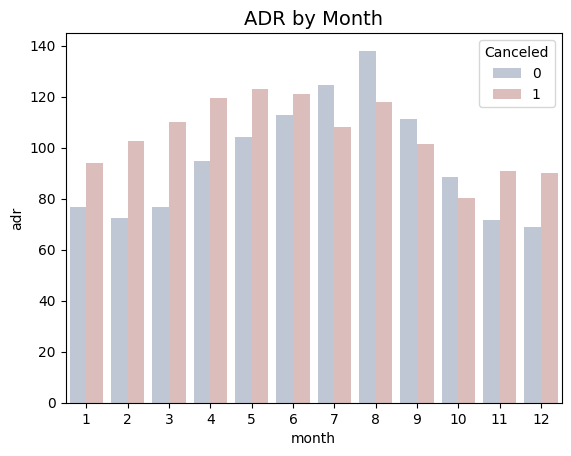

In [777]:
data = (
    df_clean
    .groupby(['month','is_canceled'])['adr']
    .mean()
    .reset_index()
)

plt.title('ADR by Month', size = 14)
sns.barplot(x='month', y='adr', hue='is_canceled', palette = 'vlag', data=data)

plt.legend(title='Canceled')

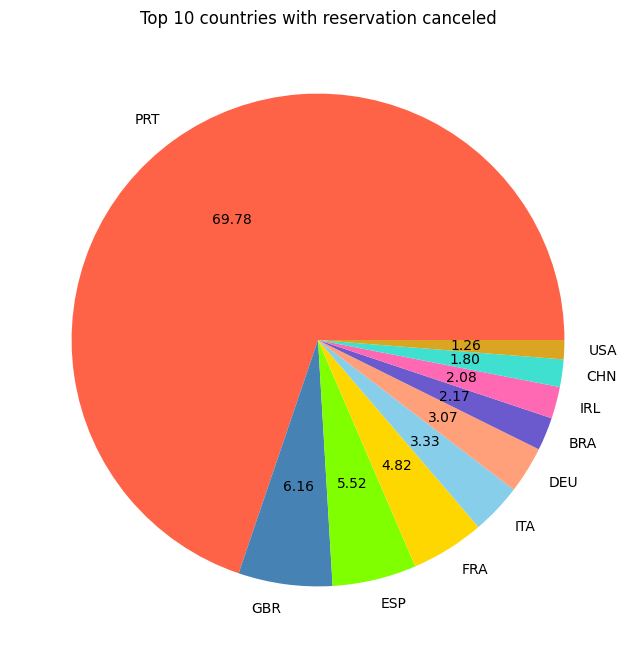

In [778]:
cancelled_data= df_clean[df_clean['is_canceled']==1]
top_10_country = cancelled_data['country'].value_counts()[:10]

# Custom colors for the pie chart
custom_colors = ['#FF6347', '#4682B4', '#7FFF00', '#FFD700', '#87CEEB', '#FFA07A', '#6A5ACD', '#FF69B4', '#40E0D0', '#DAA520']

plt.figure(figsize=(8, 8)) 
plt.title('Top 10 countries with reservation canceled', color="black")
plt.pie(top_10_country, autopct='%.2f', labels=top_10_country.index, colors=custom_colors)
plt.show()

In [779]:
df_clean['total_guests'] = (
    df_clean['adults'] + 
    df_clean['children'].fillna(0) + 
    df_clean['babies']
)

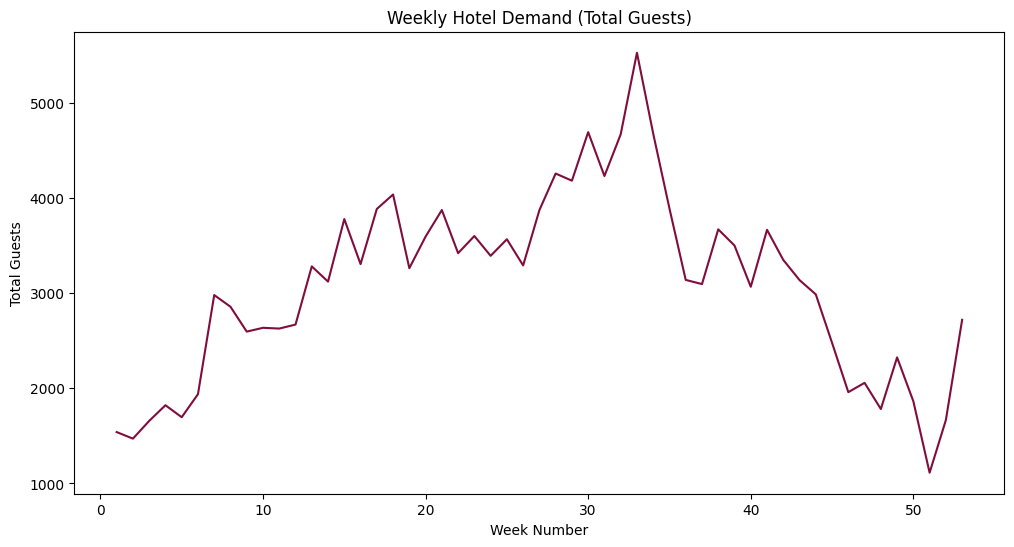

In [780]:
weekly = (
    df_clean
    .groupby('arrival_date_week_number')['total_guests']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=weekly, x='arrival_date_week_number', y='total_guests', color='#800d3d')
plt.title('Weekly Hotel Demand (Total Guests)')
plt.xlabel('Week Number')
plt.ylabel('Total Guests')
plt.show()

The line chart shows a clear seasonal pattern in hotel demand across the year.
- Demand starts relatively low at the beginning of the year (around week 1–5).
- It gradually increases from week 6 onward, indicating growing booking activity.
- The demand reaches its peak around week 30–33, with the highest number of guests.
- After the peak, there is a sharp decline, followed by fluctuating demand.
- Toward the end of the year (week 45+), demand drops significantly, reaching its lowest point before slightly increasing again.

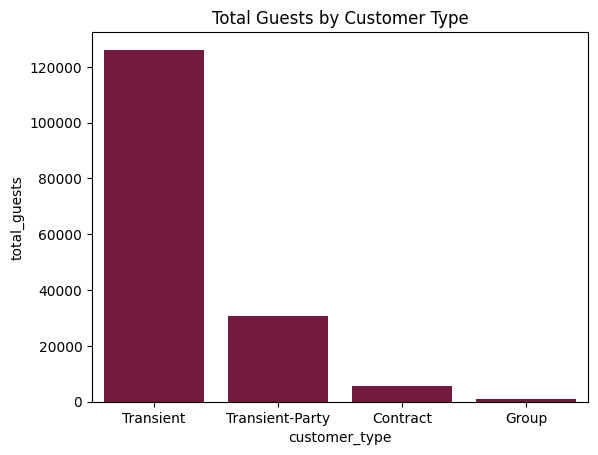

In [781]:
cust = (
    df_clean
    .groupby('customer_type')['total_guests']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=cust, x='customer_type', y='total_guests', color='#800d3d')
plt.title('Total Guests by Customer Type')
plt.show()

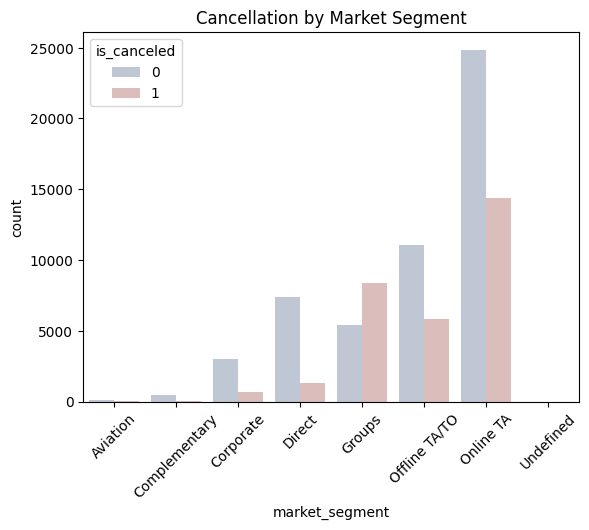

In [782]:
cancel = (
    df_clean
    .groupby(['market_segment','is_canceled'])
    .size()
    .reset_index(name='count')
)

sns.barplot(data=cancel, x='market_segment', y='count', hue='is_canceled', palette = 'vlag')
plt.xticks(rotation=45)
plt.title('Cancellation by Market Segment')
plt.show()

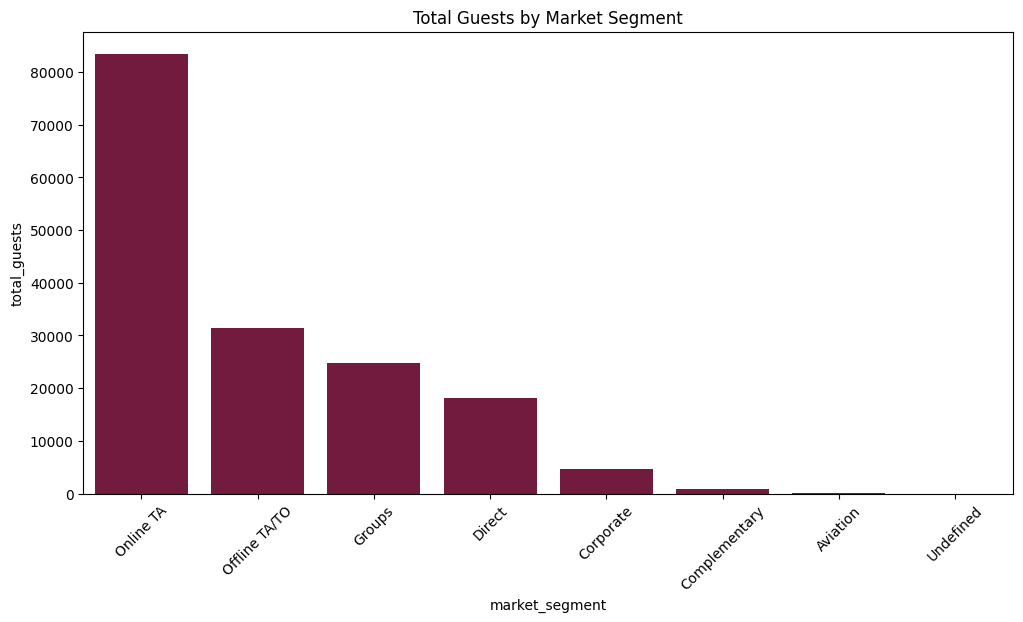

In [783]:
seg = (
    df_clean
    .groupby('market_segment')['total_guests']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=seg, x='market_segment', y='total_guests', color='#800d3d')
plt.xticks(rotation=45)
plt.title('Total Guests by Market Segment')
plt.show()

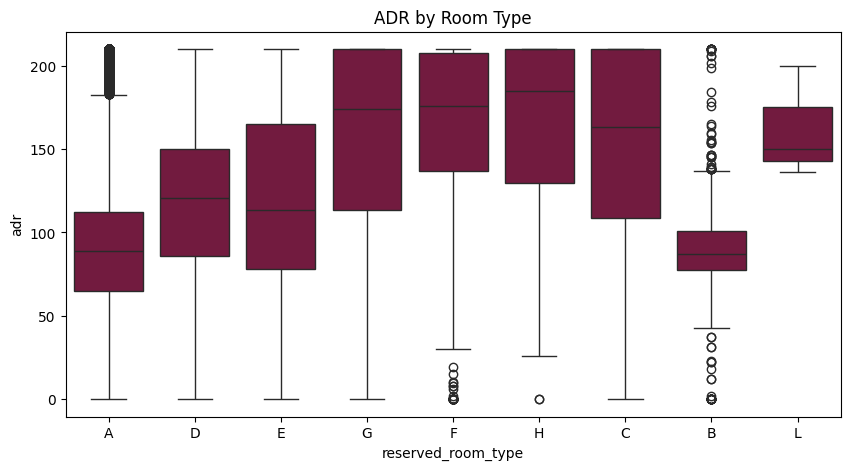

In [784]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='reserved_room_type', y='adr', color='#800d3d')
plt.title('ADR by Room Type')
plt.show()

Higher room types (H, G, F) consistently generate higher ADR, indicating strong revenue contribution from premium segments

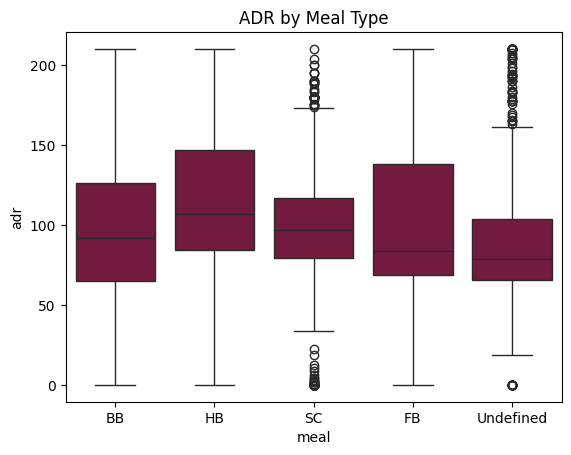

In [785]:
sns.boxplot(data=df_clean, x='meal', y='adr', color='#800d3d')
plt.title('ADR by Meal Type')
plt.show()

Meal packages, particularly Half Board (HB), are associated with higher ADR, suggesting that bundled offerings can significantly increase revenue

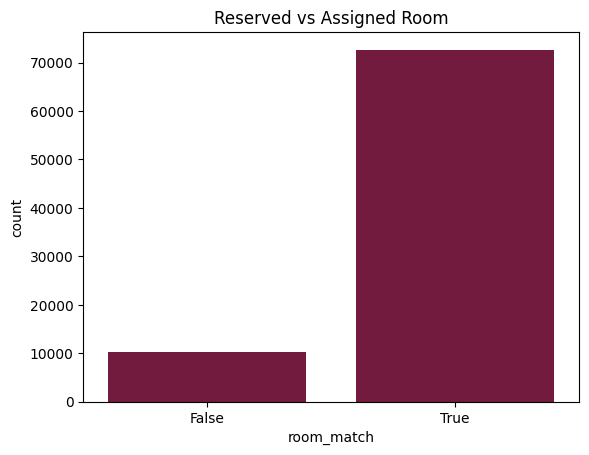

In [786]:
df_clean['room_match'] = (
    df_clean['reserved_room_type'] == df_clean['assigned_room_type']
)

sns.countplot(data=df_clean, x='room_match', color='#800d3d')
plt.title('Reserved vs Assigned Room')
plt.show()

The bar chart compares whether guests received the same room type they initially reserved.

The majority of bookings fall under "True", meaning:

👉 Most guests received the exact room they booked.

A smaller portion falls under "False", indicating:

👉 Some guests were assigned a different room type than reserved.

In [792]:
# menyimpan kedalam excel
df_clean.to_excel("hotel_cleaning.xlsx", index=False)